In [1]:
#All packages needed to run TwINFER simulation and inference are listed here. 
#If any of them are not installed, please install them using pip or conda env.
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numba
import tqdm
import scipy
import seaborn
import scipy
import os
import sys
import joblib
from itertools import product
import joblib 
import importlib

# Code to simulate a synthetic GRN and infer the network using TwINFER


## Details about the simulation

### Set this for both running the simulation and before inferring using TwINFER


In [75]:
#Path to TwINFER code repository
import os, sys
path_to_code_repo = os.path.abspath(getattr(sys.modules['__main__'], '__file__', os.getcwd()))

#Common path to data files
path_to_data = f"{path_to_code_repo}/simulation_example_input_data"
path_to_output = f"{path_to_code_repo}/simulation_example_output_data"

base_config = {
    'n_cells': 6000, #Number of cells before division (number of twin pairs)
    'simulation_time_before_division': 1500, #The time used to run the initial cells before division. User must set this time to ensure the population reaches steady state [hours]
    'twin_simulation_time_after_division': 24, #The time twin cells are simulated after division and measurements are stored in the output[hours]
    'twin_measurement_resolution': 1, #The time between each measurement of twin cells [hours]. For example, if twin_sampling_duration is 12 and twin_measurement_resolution is 1, the final dataframe will contain hourly measurements for 12 hours (0 is birth).
    "path_to_connectivity_matrix": f"{path_to_data}/connectivity_matrix_5_gene_linear_cascade.txt", #path to the connectivity matrix specifying the GRN to simulate
    "param_csv": f"{path_to_data}/median_parameter.csv", #Path to the parameters for all genes and interaction terms
    "rows_to_use": [[0, 0, 0, 0, 0]], #Rows in the parameter's csv file for each gene. Example - [0,0] will mean use row 0 parameters for both gene 1 and 2. The length should be equal to number of genes in the system. Ensure that each row in the parameter.csv has unique index.
    "output_folder": f"{path_to_output}", #Path to the output folder
    "log_file": f"{path_to_output}/log.jsonl", #Path to the log file
    "multiple_interaction_type": "additive", #Model if there are multiple regulators acting on a single gene - options are additive, or, and.
    "type": "Five_gene_cascade",  # Name of the network used -- will be in the filename
    "number_of_parallel_parameters": 1, #Number of parameters to be run in parallel
    "number_of_cores_per_parameter": 2, #Number of cores to be used per parameter (number_of_parallel_parameters * number_of_cores_per_parameter = number of cores in your computer)
}

## Functions and packages used in this notebook - run this everytime notebook is restarted


### For the simulation


In [3]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import set_num_threads, get_num_threads

sys.path.append(str(path_to_code_repo))
set_num_threads(base_config['number_of_cores_per_parameter'])
print("Threads Numba will use:", get_num_threads())

import importlib
from TwINFER_function_scripts import gillespie_script_variations
importlib.reload(gillespie_script_variations)
from TwINFER_function_scripts.gillespie_script_variations import process_param_set

Threads Numba will use: 9


### For inferring with TwINFER


In [4]:
# Calculation functions
import importlib
from TwINFER_function_scripts import correlation_analysis_functions
from TwINFER_function_scripts import correlation_analysis_helpers
from TwINFER_function_scripts import infer_with_twinfer

importlib.reload(correlation_analysis_functions)
importlib.reload(correlation_analysis_helpers)
importlib.reload(infer_with_twinfer)

from TwINFER_function_scripts.correlation_analysis_functions import (
    
    calculate_pairwise_gene_gene_correlation_matrix,
    check_system_in_steady_state,
    check_gene_gene_correlation_threshold,
    calculate_twin_random_pair_correlations,
    differentiate_single_state_reg_and_multiple_states,
    identify_reg_if_multiple_states,
    get_cross_correlations,
    identify_actual_directed_edges
)

# Helper functions
from TwINFER_function_scripts.correlation_analysis_helpers import (
    extract_param_index,
    read_input_matrix,
    get_param_data, 
    plot_matrix_as_heatmap,
    print_summary,
    plot_network
)

from TwINFER_function_scripts.infer_with_twinfer import (
    infer_with_twinfer
)

## Simulate the gene expression in a population of cells

The code simulates gene expression based on a GRN (described by the interaction matrix) and expression of each gene is defined by parameters (each row in the parameter sheet) using the Gillespie algorithm.


In [ ]:
os.makedirs(base_config['output_folder'], exist_ok=True)
rows_to_use = base_config['rows_to_use']
labels = ["rows_" + "_".join(map(str, row)) for row in rows_to_use]
path_to_simulation_file = process_param_set(rows_to_use[0], labels[0], base_config)
print(f"Saved the simulation file as {path_to_simulation_file}")

# Using TwINFER to infer network from the simulation

### Before starting, set the time-points used as t1 and t2. The default is 1 hour and 20 hours after division.

TwINFER uses three kinds of correlations used for distinguishing multiple-states and regulation.

- First, calculate gene-gene correlations $\rho$ for all pairs of genes at time t1. This will identify gene-pairs that are potentially interacting.
- Second, calculate twin pair correlation $\hat{\rho}_{\Delta}$ and random pair correlation. Comparing these two for all gene pairs will detect the existence of multiple states in the population vs just regulation.
- Finally, if there are multiple states in the population, compare twin pair correlation $\hat{\rho}_{\Delta}$ at time t1 and time t2. This will detect the existence of regulatory interaction.

Next, if there is regulation and single-state in the population, TwINFER can identify direction of regulatory interaction. This is done be comparing cross-correlations between twins at the two timepoints.

### Based on this algorithm, a network will be inferred and plotted.


### Input to TwINFER


### Run TwINFER for inference using the simulation, base_config, t1 and t2.


In [25]:
twinfer_kwargs = {
    "path_to_simulation_file": path_to_simulation_file,
    "base_config": base_config,
    "t1": 1,  #time [hours] after division when t1 sample is collected
    "t2": 20, #time [hours] after division when t2 sample is collected
    "check_for_steady_state": True,
    "threshold_gene_gene_corr": 0.04, #Use direct threshold (used ONLY if use_scramble is False)
    "use_scramble": True, #If set to true, set the p_val_threshold_scrambled_gene_correlation;threshold_gene_gene_corr will NOT be used
    "p_val_threshold_scrambled_gene_correlation": 0.01, #used ONLY if use_scramble is True
    "show_scrambled_distribution_gene_correlation": True, 
    "z_score_threshold_two_states": 10, #Z-score threshold to detect multi-states in the system
    "p_value_threshold_cross_correlation": 0.01,
    "plot_correlation_matrices_as_heatmap": True,
    "have_any_output": True,
    "seed": 101010,
    "infer_direction_for_which_edges": "all-regulation", #can be either single-state, all-regulation or all-edges,
    "merge_time_points": True, #If True, then cells from the two timepoints will be used to calculate gene correlations and random-pair difference correlations
    "n_cores": 4,
}

In [ ]:
correlation_matrices = infer_with_twinfer(**twinfer_kwargs)

## Export the matrices as a json file for reuse

In [76]:
import json
def make_json_safe(obj):
    if hasattr(obj, "to_dict"):      # pandas DataFrame / Series
        return obj.to_dict()
    if isinstance(obj, set):
        return list(obj)
    return obj

json_safe = {
    k: make_json_safe(v)
    for k, v in correlation_matrices.items()
}

path_to_json_file = f"{path_to_output}/{base_config['type']}_correlation_matrices.json"
with open(path_to_json_file, "w") as f:
    json.dump(json_safe, f, indent=2)


## Plotting and saving correlation matrices

In [65]:
#Set path to plots if you want to save them - if None, the plots will be displayed, not saved
path_to_plots = None

In [63]:
path_to_json_file = f"{path_to_output}/{base_config['type']}_correlation_matrices.json"
with open(path_to_json_file, "r") as f:
    correlation_matrices = json.load(f)

print(correlation_matrices.keys())

dict_keys(['all_gene_pairs', 'gene_lists', 'potential_regulation', 'final_directed_edges', 'direction_matrix', 'unfiltered_direction_matrix', 'pairwise_gene_gene_correlation_matrix', 'twin_pair_correlation_matrix_t2', 'random_pair_correlation_matrix_t2', 'twin_pair_correlation_matrix_t1', 'random_pair_correlation_matrix_t1'])


### Helper functions and settings for the plot

In [28]:
import matplotlib.font_manager as fm
# ============================================================
# Fonts / style
# ============================================================
font_paths = [
    f"{path_to_code_repo}/fonts/Arial.ttf",
     f"{path_to_code_repo}/fonts/Arial Bold.ttf",
     f"{path_to_code_repo}/fonts/Arial Italic.ttf",
     f"{path_to_code_repo}/fonts/Arial Bold Italic.ttf",
]

for fp in font_paths:
    try:
        fm.fontManager.addfont(fp)
        print("✔ Loaded font:", fp)
    except Exception as e:
        print("⚠️  Could not load:", fp, "|", e)

# ==== LaTeX + SVG text mode (Illustrator-safe) ====
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18     # x/y labels
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 12     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12    # legend text

✔ Loaded font: /home/gzu5140/Font/Arial.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Bold.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Italic.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Bold Italic.ttf


In [29]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Rectangle
import seaborn as sns
from pathlib import Path

def make_reds_blues_colormap(vmin=-0.05, vmax=0.18):
    """Custom red–white–blue colormap with pure white at 0, asymmetric."""
    # Calculate where 0 falls in the range [vmin, vmax]
    zero_position = (0 - vmin) / (vmax - vmin)
    
    # Number of colors for each segment (proportional to range)
    n_total = 256
    n_reds = int(zero_position * n_total)  # colors from vmin to 0
    n_blues = n_total - n_reds  # colors from 0 to vmax
    
    # Calculate intensity based on actual distance from zero
    # For reds: map from vmin to 0, so max intensity at vmin
    red_intensity = abs(vmin) / max(abs(vmin), abs(vmax))  # 0.05/0.18 ≈ 0.28
    # For blues: map from 0 to vmax, so max intensity at vmax  
    blue_intensity = abs(vmax) / max(abs(vmin), abs(vmax))  # 0.18/0.18 = 1.0
    
    # Create color arrays with scaled intensities
    reds = plt.cm.Reds(np.linspace(0.8 * red_intensity, 0, n_reds))  # scaled dark to light red
    whites = np.ones((1, 4))  # pure white at 0
    blues = plt.cm.Blues(np.linspace(0, 0.8 * blue_intensity, n_blues))  # light to scaled dark blue
    
    colors = np.vstack((reds, whites, blues))
    return LinearSegmentedColormap.from_list('RedsBlues', colors)

In [73]:
pairwise_gene_gene_correlation_matrix = pd.DataFrame(correlation_matrices['pairwise_gene_gene_correlation_matrix'])
all_gene_pairs = correlation_matrices['all_gene_pairs']
final_directed_edges = correlation_matrices['final_directed_edges']
potential_regulation = correlation_matrices['potential_regulation']
unfiltered_direction_matrix = pd.DataFrame(correlation_matrices['unfiltered_direction_matrix'])
multiple_states_and_reg = correlation_matrices['gene_lists']['multiple_states_and_reg']

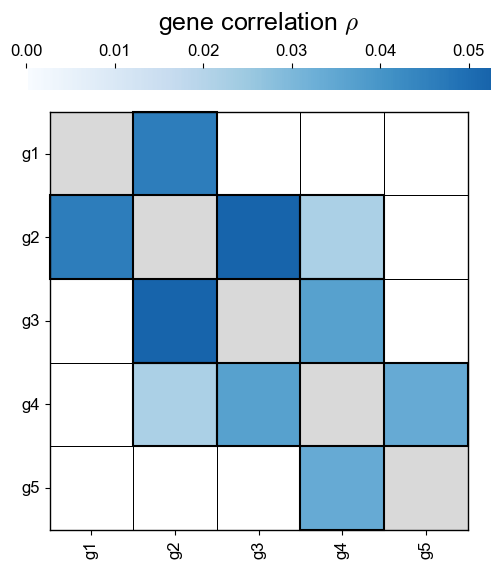

In [71]:
#Plot gene-correlation data
gene_list = sorted(
    {g for pair in all_gene_pairs for g in pair},
    key=lambda x: int(x.split("_")[1])
)
gene_labels = [f"g{g.split('_')[1]}" for g in gene_list]
pairwise_gene_gene_correlation_matrix = pairwise_gene_gene_correlation_matrix.loc[gene_list, gene_list]
data_matrix = pairwise_gene_gene_correlation_matrix.to_numpy(float)
np.fill_diagonal(data_matrix, np.nan)
fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
cbar_ax = fig.add_subplot(gs[0])
heatmap_ax = fig.add_subplot(gs[1])

plot_matrix = data_matrix.copy()
plot_matrix[:] = 0.0

# Restore only potential regulation correlations
for g1, g2 in potential_regulation:
    if g1 in gene_list and g2 in gene_list:
        i = gene_list.index(g1)
        j = gene_list.index(g2)
        plot_matrix[i, j] = data_matrix[i, j]
        plot_matrix[j, i] = data_matrix[j, i]
np.fill_diagonal(plot_matrix, np.nan)
vmin = np.nanmin(plot_matrix)
vmax = np.nanmax(plot_matrix)

cmap = make_reds_blues_colormap(vmin = vmin, vmax = vmax)
cmap.set_bad(color="#D9D9D9")

sns.heatmap(
    plot_matrix,
    ax=heatmap_ax,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    square=True,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={'orientation': 'horizontal'},
    linewidths=0.5,
    linecolor="black",
    # center=center
)

gene_to_idx = {g: i for i, g in enumerate(gene_list)}
for g1, g2 in potential_regulation:
    if g1 in gene_to_idx and g2 in gene_to_idx:
        i = gene_to_idx[g1]
        j = gene_to_idx[g2]

        for (x, y) in [(j, i), (i, j)]:
            rect = Rectangle(
                (x, y), 1, 1,
                fill=False,
                edgecolor="black",
                linewidth=1.5,
                clip_on=False
            )
            heatmap_ax.add_patch(rect)
        
cbar_ax.xaxis.set_label_position('top')
cbar_ax.set_xlabel(r"gene correlation $\rho$", labelpad=10)
cbar_ax.xaxis.tick_top()

heatmap_ax.set_xticklabels(gene_labels, rotation=90, ha="center", va="top")
heatmap_ax.set_yticklabels(gene_labels, rotation=0, ha="right", va="center")
# --- transparent background ---
# plt.tight_layout()
fig.patch.set_alpha(0)
for ax in [heatmap_ax, cbar_ax]:
    ax.set_facecolor("none")
for im in heatmap_ax.get_images() + cbar_ax.get_images():
    im.set_facecolor((1, 1, 1, 0))
    im.set_edgecolor((1, 1, 1, 0))
for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')
    spine.set_clip_on(False)

# --- save ---

if path_to_plots:
    out = Path(path_to_plots)
    out.mkdir(parents=True, exist_ok=True)
    matrix_type = "gene_correlation"
    png_path = out / f"{matrix_type}.png"
    svg_path = out / f"{matrix_type}.svg"
    pdf_path = out / f"{matrix_type}.pdf"
    plt.savefig(png_path, dpi=300, bbox_inches='tight', transparent=True)
    fig.savefig(svg_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='svg')
    fig.savefig(pdf_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='pdf')
    print(f"Saved PNG: {png_path}")
    print(f"Saved SVG: {svg_path}")
    plt.show()
# # else:
plt.show()

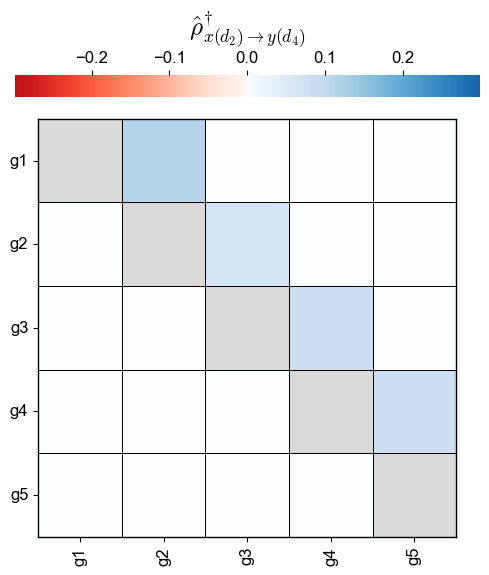

In [78]:
#Plot TwINFER output
gene_list = sorted(
    {g for pair in all_gene_pairs for g in pair},
    key=lambda x: int(x.split("_")[1])
)
gene_labels = [f"g{g.split('_')[1]}" for g in gene_list]
# direction_matrix = unfiltered_direction_matrix.loc[gene_list, gene_list]
data_matrix = unfiltered_direction_matrix.to_numpy(float)
masked_matrix = np.fill_diagonal(data_matrix, np.nan)
fig = plt.figure(figsize=(6,6))
gs = fig.add_gridspec(2, 1, height_ratios=[0.05, 0.95], hspace=0.1)
cbar_ax = fig.add_subplot(gs[0])
heatmap_ax = fig.add_subplot(gs[1])
plot_matrix = data_matrix.copy()
plot_matrix[:] = 0.0

# Restore only final-ege correlations
for g1, g2 in final_directed_edges:
    if g1 in gene_list and g2 in gene_list:
        i = gene_list.index(g1)
        j = gene_list.index(g2)
        plot_matrix[i, j] = data_matrix[i, j]
        plot_matrix[j, i] = data_matrix[j, i]
np.fill_diagonal(plot_matrix, np.nan)
vmin = -0.299
vmax = 0.299
cmap = make_reds_blues_colormap(vmin = vmin, vmax = vmax)

cmap.set_bad(color="#D9D9D9")
# --- draw heatmap ---
sns.heatmap(
    plot_matrix,
    ax=heatmap_ax,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    square=True,
    cbar=True,
    cbar_ax=cbar_ax,
    cbar_kws={'orientation': 'horizontal'},
    linewidths=0.5,
    linecolor="black",
    # center=center
)
for g1, g2 in multiple_states_and_reg:
    if g1 in gene_list and g2 in gene_list:
        i = gene_list.index(g1)
        j = gene_list.index(g2)
        print(i, j)

        # Draw diagonal in cell (i, j) - top-left to bottom-right
        heatmap_ax.plot(
            [j, j+1],      # x: left → right
            [i, i+1],      # y: top → bottom
            linestyle="--",
            color="black",
            linewidth=1.5,
            clip_on=False
        )
        
        # Draw diagonal in symmetric cell (j, i) - top-left to bottom-right
        heatmap_ax.plot(
            [i, i+1],      # x: left → right
            [j, j+1],      # y: top → bottom
            linestyle="--",
            color="black",
            linewidth=1.5,
            clip_on=False
        )

# --- labels ---
cbar_ax.xaxis.set_label_position('top')
cbar_ax.set_xlabel(r"$\hat{\rho}^{\dagger}_{x(d_{2}) \to y(d_{4})}$", labelpad=10)
cbar_ax.xaxis.tick_top()

heatmap_ax.set_xticklabels(gene_labels, rotation=90, ha="center", va="top")
heatmap_ax.set_yticklabels(gene_labels, rotation=0, ha="right", va="center")
# --- transparent background ---
# plt.tight_layout()
fig.patch.set_alpha(0)
for ax in [heatmap_ax, cbar_ax]:
    ax.set_facecolor("none")
for im in heatmap_ax.get_images() + cbar_ax.get_images():
    im.set_facecolor((1, 1, 1, 0))
    im.set_edgecolor((1, 1, 1, 0))
for spine in heatmap_ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')
    spine.set_clip_on(False)

# --- save ---
if path_to_plots:
    out = Path(path_to_plots)
    out.mkdir(parents=True, exist_ok=True)
    matrix_type = "direction_correlation"
    png_path = out / f"{matrix_type}.png"
    svg_path = out / f"{matrix_type}.svg"
    pdf_path = out / f"{matrix_type}.pdf"
    plt.savefig(png_path, dpi=300, bbox_inches='tight', transparent=True)
    fig.savefig(svg_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='svg')
    fig.savefig(pdf_path, bbox_inches='tight', transparent=True,
                facecolor='none', edgecolor='none', format='pdf')
    print(f"Saved PNG: {png_path}")
    print(f"Saved SVG: {svg_path}")
    plt.show()
# # else:
plt.show()